## Synch - Kuramoto order parameter (T11, T12)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.animation import FuncAnimation
%matplotlib inline
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.io import loadmat
import scipy.io as sio
from scipy.signal import hilbert
import os
from os.path import isfile,isdir,join
from os import listdir

### Read data

In [2]:
df = pd.read_parquet ('data/datos.pqt')

In [3]:
df.shape

(85320, 13)

In [4]:
pd.options.display.float_format = '{:.8g}'.format

In [5]:
df.describe()

,FormacionNIRHumedadPV,FibraticPredNIRHumedadPV,BasculaMantaPesoPV,SierrasAnchoPV,FormacionMantaCentroAltura,FormacionAlturaMantaPV,FormacionVelocidadSP,FormacionVelocidad,FormacionMantaSupMWEntT10TempPV,FormacionMWEntT11TempPV,MWPotenciaPV,FormacionMWSalT12TempPV
count,85320,85320,85320,85320,85320,85320,85320,85320,85320,85320,85320,85320
mean,8.2108424,8.6014914,11.448445,2264.6346,80.892935,118.6002,422.20816,407.62263,33.850545,39.841404,324.14324,46.453422
std,0.95202824,1.1503395,2.5211389,191.72412,16.64495,88.241268,107.10594,125.21832,1.6976404,1.7056432,87.968905,2.6147454
min,3.413913,3.756606,3.132666,1893.09,4.379944,62.28998,270,0,29.8,30.03584,0,30.35776
25%,7.829252,8.3031645,8.5007998,2143.39,61.91687,80.16498,340,339.9,33.1,38.79044,317.706,45.85693
50%,8.270703,8.737867,12.80372,2143.52,86.751645,101.88,380,380,33.9,40.00745,325.46835,46.92476
75%,8.705579,9.3150813,12.93289,2491.52,93.04083,109.22125,500,500,34.8,40.99283,381.6813,47.69814
max,11.26585,11.25496,15.27589,2564.43,113.832,522.915,690,690.2,38.2,44.45934,411.1483,52.39736


In [6]:
index_ini = 80900
index_fin = 82700
window = 60
lag = int(18600/df['FormacionVelocidad'].iloc[index_ini:index_fin].mean())

In [7]:
varA = df['FormacionMWEntT11TempPV'].iloc[index_ini-lag:index_fin-lag].rolling(window).mean()-df['FormacionMWEntT11TempPV'].iloc[index_ini-lag:index_fin-lag].mean()
varA = varA.dropna(how='any')
varA = varA.reindex()
time = varA.index
varA = np.concatenate((varA[::-1], varA))

In [8]:
len(time)

1741

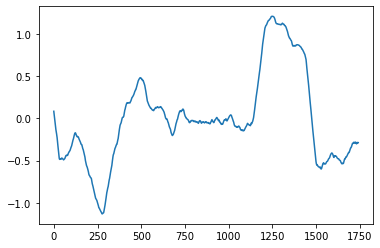

In [9]:
plt.plot(varA[len(time):])

In [10]:
varB = df['FormacionMWSalT12TempPV'].iloc[index_ini:index_fin].rolling(window).mean()-df['FormacionMWSalT12TempPV'].iloc[index_ini:index_fin].mean()
varB = varB.dropna(how='any')
varB = varB.reindex()
varB = np.concatenate((varB[::-1], varB))

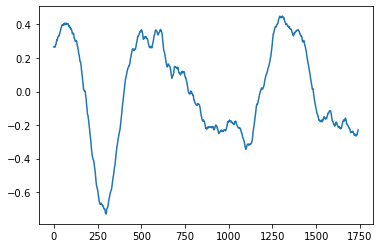

In [11]:
plt.plot(varB[len(time):])

### Hilbert transforms

Analytic signal:
$\zeta(t)=s(t)+i s_H(t)=A e^{i\phi(t)}$,

where:
- $A(t)$: instantaneous amplitude of the signal $s(t)$
- $\phi(t)$: instantaneous phase of the signal $s(t)$
- $s_H(t)=\frac{1}{\pi} P.V. \int_{-\infty}^{\infty} \frac{s(\tau)}{t-\tau} d\tau$: Hilbert transform of the signal $s(t)$

In [12]:
hil_evol_A = hilbert(varA)
hil_evol_A = hil_evol_A[len(time):]

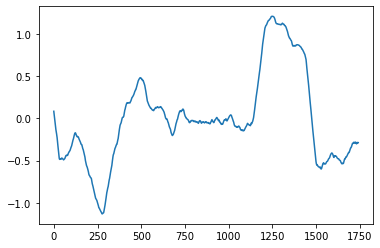

In [13]:
plt.plot(hil_evol_A.real)

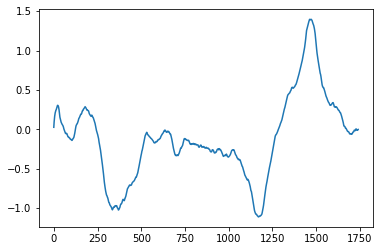

In [14]:
plt.plot(hil_evol_A.imag)

In [15]:
hil_evol_B = hilbert(varB)
hil_evol_B = hil_evol_B[len(time):]

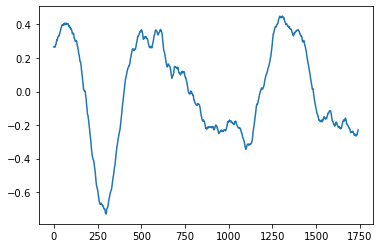

In [16]:
plt.plot(hil_evol_B.real)

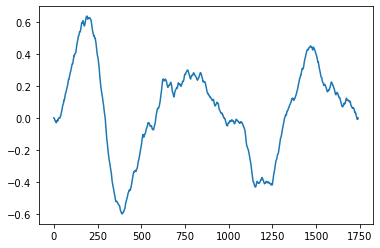

In [17]:
plt.plot(hil_evol_B.imag)

### Phases

In [18]:
ph_evol_A = np.arctan2(hil_evol_A.imag, hil_evol_A.real)

In [19]:
ph_evol_B = np.arctan2(hil_evol_B.imag, hil_evol_B.real)

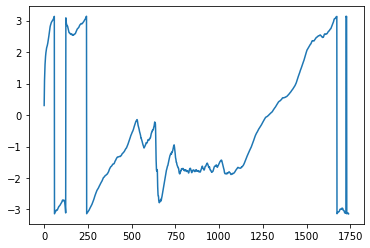

In [20]:
plt.plot(ph_evol_A)

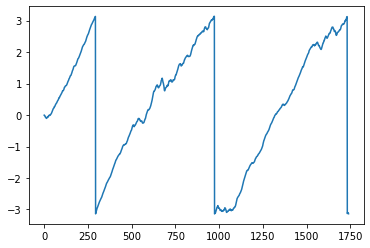

In [21]:
plt.plot(ph_evol_B)

### Kuramoto order parameter

In [22]:
R_A = np.exp(1j*ph_evol_A)
R_A = np.abs(R_A)

In [23]:
R_B = np.exp(1j*ph_evol_B)
R_B = np.abs(R_B)

In [24]:
R = (np.exp(1j*ph_evol_A)+np.exp(1j*ph_evol_B))/2
R = np.abs(R)
R.mean()

0.7826410917884037

Text(0.5, 1.0, 'Kuramoto order parameter')

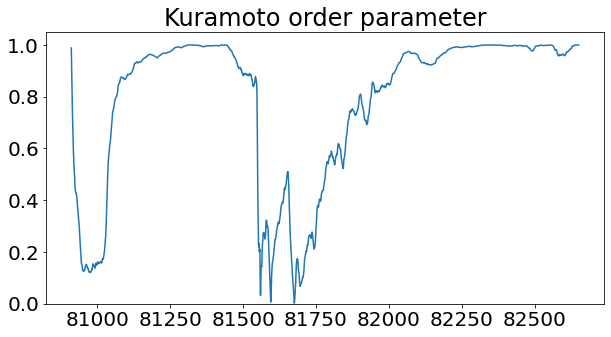

In [25]:
fig,ax = plt.subplots(figsize=(10,5))
plt.plot(time,R)
plt.ylim([0,1.05])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Kuramoto order parameter', fontsize=24)

### State space diagrams and phases plots

Text(0.5, 1.0, 'State space for amplitudes')

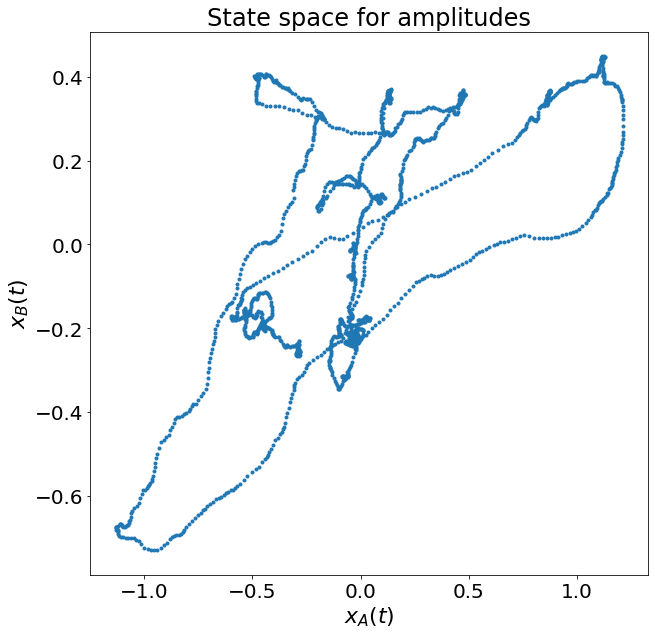

In [26]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_A.real,hil_evol_B.real,'.')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$x_A (t)$', fontsize=22)
plt.ylabel('$x_B (t)$', fontsize=22)
plt.title('State space for amplitudes', fontsize=24)

Text(0.5, 1.0, 'State space for phases')

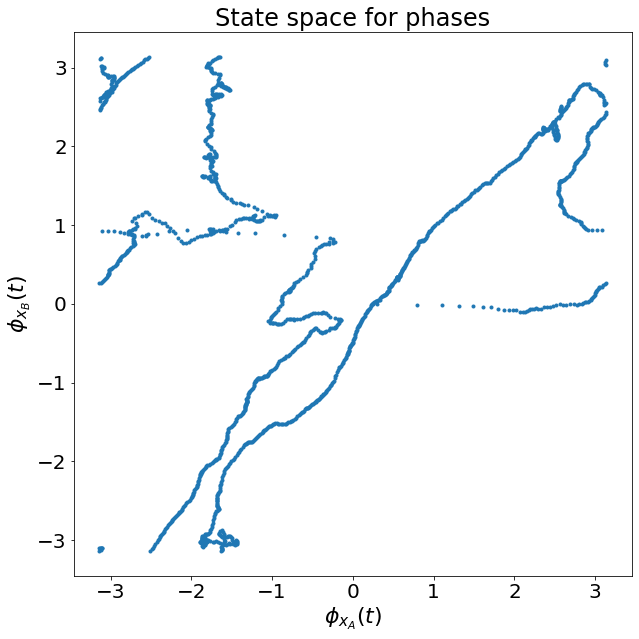

In [27]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(ph_evol_A,ph_evol_B,'.')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\phi_{x_A} (t)$', fontsize=22)
plt.ylabel('$\phi_{x_B} (t)$', fontsize=22)
plt.title('State space for phases', fontsize=24)

In [28]:
theta = np.linspace(-np.pi, np.pi, 100)

Text(0.5, 1.0, 'Phases')

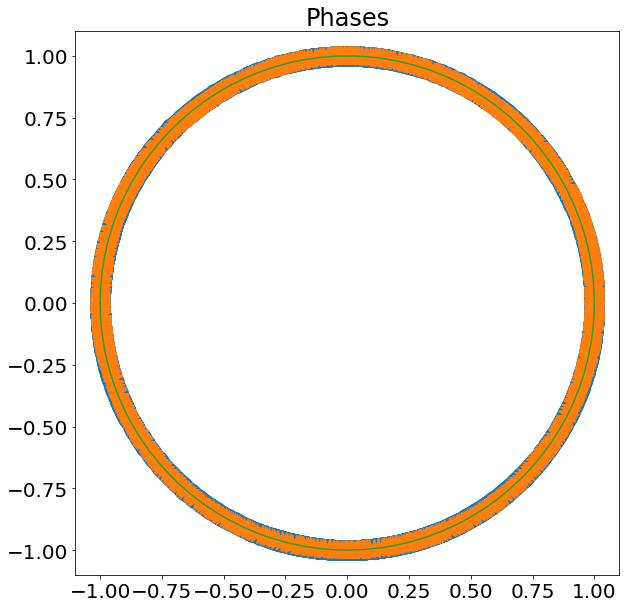

In [29]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(ph_evol_A),np.sin(ph_evol_A),'o',np.cos(ph_evol_B),np.sin(ph_evol_B),'*',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phases', fontsize=24)
#plt.savefig('figures/phases.pdf')


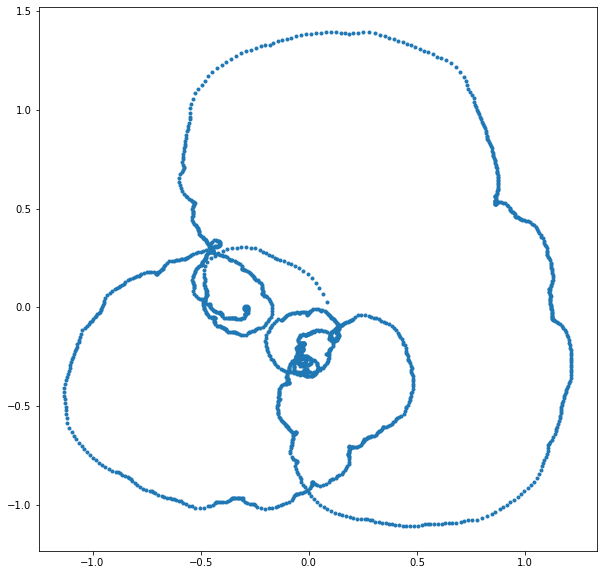

In [30]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_A.real,hil_evol_A.imag,'.')
#ax.set_aspect(1)

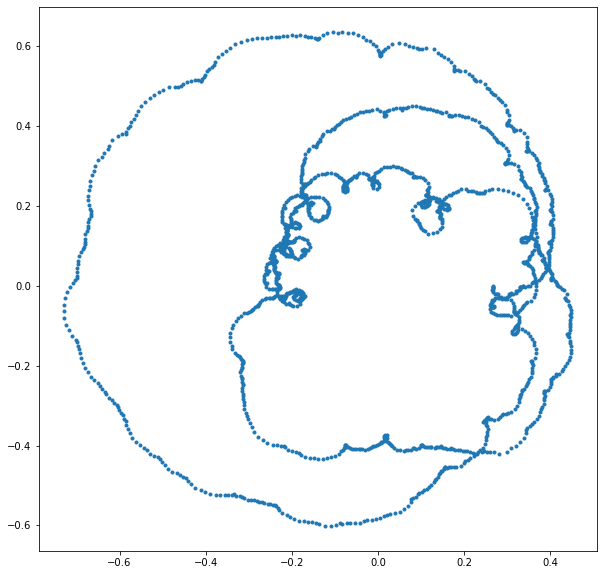

In [31]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(hil_evol_B.real,hil_evol_B.imag,'.')
#ax.set_aspect(1)

In [32]:
phA_B=np.arctan2(hil_evol_A.imag*hil_evol_B.real-hil_evol_A.real*hil_evol_B.imag, hil_evol_A.real*hil_evol_B.real+hil_evol_A.imag*hil_evol_B.imag)

Text(0.5, 1.0, 'Phase difference')

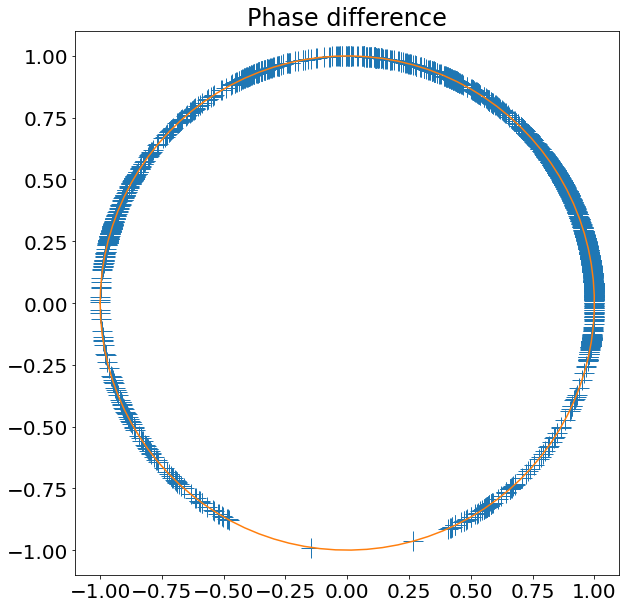

In [33]:
fig,ax = plt.subplots(figsize=(10,10))
plt.plot(np.cos(phA_B),np.sin(phA_B),'+',np.cos(theta), np.sin(theta), '-', markersize=20)
ax.set_aspect(1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff_circ.pdf')

Text(0.5, 1.0, 'Phase difference')

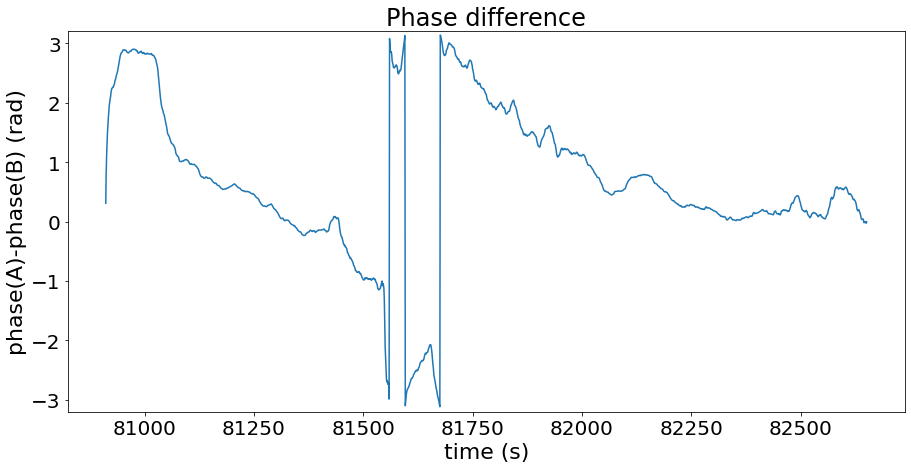

In [34]:
fig,ax = plt.subplots(figsize=(15,7))
plt.plot(time,(phA_B), '-', markersize=20)
plt.ylim([-3.2,3.2])
plt.xlabel('time (s)', fontsize=22)
plt.ylabel('phase(A)-phase(B) (rad)', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Phase difference', fontsize=24)
#plt.savefig('figures/phases_diff.pdf')

### Recurrence plot

In [39]:
def recurrence_plot(data, threshold=0.1):
    """
    Recurrence plot from a time series
    
    :param data: Time series data
    :param threshold: Threshold to determine recurrence
    :return: Recurrence plot
    """
    # Calculate the distance matrix
    N = len(data)
    distance_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            distance_matrix[i,j] = np.abs(data[i] - data[j])
            
    # Create the recurrence plot
    recurrence_plot = np.where(distance_matrix <= threshold, 1, 0)
    
    return recurrence_plot

<function matplotlib.pyplot.show(close=None, block=None)>

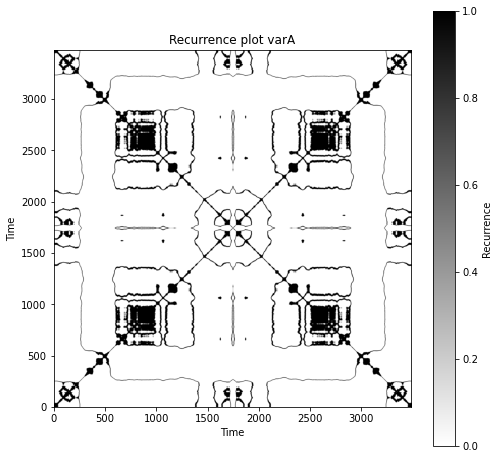

In [43]:
recA = recurrence_plot(varA, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recA, cmap='binary', origin='lower')
plt.title('Recurrence plot varA')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

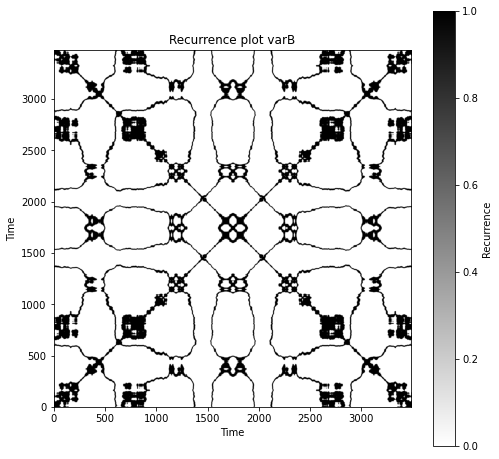

In [44]:
recB = recurrence_plot(varB, threshold=0.05)

plt.figure(figsize=(8, 8))
plt.imshow(recB, cmap='binary', origin='lower')
plt.title('Recurrence plot varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Recurrence')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

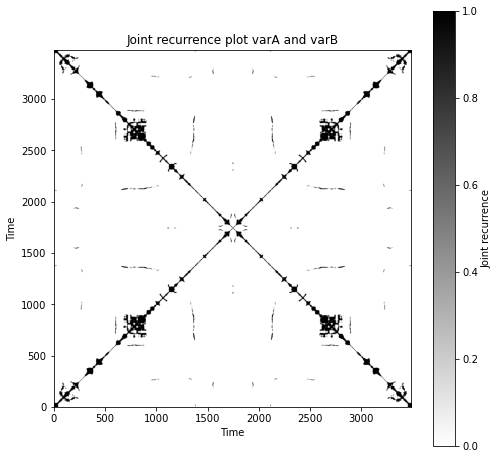

In [45]:
joint_rec = recA*recB

plt.figure(figsize=(8, 8))
plt.imshow(joint_rec, cmap='binary', origin='lower')
plt.title('Joint recurrence plot varA and varB')
plt.xlabel('Time')
plt.ylabel('Time')
plt.colorbar(label='Joint recurrence')
plt.show